# Notebook 03 — Advanced Improvements (PRF, BM25+, Lemmatization)

This notebook evaluates three advanced IR techniques against the BM25 baseline:
1. **Pseudo-Relevance Feedback (PRF)** via Rocchio Expansion
2. **BM25+** (adding a constant $\delta$ to TF to prevent over-penalizing long documents)
3. **Advanced Preprocessing** using SpaCy Lemmatization instead of Porter Stemmer


In [1]:
import sys, os, time, math, json
from collections import defaultdict
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import spacy

from core.indexer import load_cranfield, build_inverted_index, preprocess
from core.models import rank
from core.metrics import evaluate_all

RESULTS_DIR = os.path.abspath(os.path.join('..', 'results'))
os.makedirs(RESULTS_DIR, exist_ok=True)
sns.set_theme(style='whitegrid', font_scale=1.1)

# Load baseline params
best_params = json.load(open(os.path.join(RESULTS_DIR, 'best_params.json')))
bm25_params = best_params['BM25']
print(f"BM25 Baseline Params: {bm25_params}")


BM25 Baseline Params: {'k1': 2.0, 'b': 0.75}


## 1. Load Data & Baseline

In [2]:
docs, queries, qrels = load_cranfield()
inverted_index, doc_lengths, avg_dl, N, tf_raw, vocabulary = build_inverted_index(docs)

TOP_K = 100
K = 10
all_metrics = {}

# Baseline Run
t0 = time.time()
results_baseline = {}
for qid, qtext in queries.items():
    q_tokens = preprocess(qtext)
    ranked = rank('BM25', q_tokens, inverted_index, tf_raw, doc_lengths, avg_dl, N, top_k=TOP_K, **bm25_params)
    results_baseline[qid] = [doc_id for doc_id, _ in ranked]

all_metrics['BM25 (Baseline)'] = evaluate_all(results_baseline, qrels, k=K)
print(f"BM25 Baseline MAP: {all_metrics['BM25 (Baseline)']['MAP']:.4f}")


BM25 Baseline MAP: 0.4330


## 2. Pseudo-Relevance Feedback (Rocchio for BM25)
We take the top 3 documents from the baseline run, extract their top 5 TF-IDF words, and append them to the query.

In [3]:
def get_top_terms(doc_ids, tf_raw, inverted_index, N, top_t=5):
    # Compute TF-IDF for all terms in the pseudo-relevant docs
    term_scores = defaultdict(float)
    for term, doc_tfs in tf_raw.items():
        df = len(inverted_index.get(term, {}))
        idf = math.log((N - df + 0.5) / (df + 0.5) + 1)
        for doc_id in doc_ids:
            if doc_id in doc_tfs:
                tf = doc_tfs[doc_id]
                term_scores[term] += (tf * idf)
                
    # Sort and return top T terms
    sorted_terms = sorted(term_scores.items(), key=lambda x: x[1], reverse=True)
    return [term for term, score in sorted_terms[:top_t]]

results_prf = {}
for qid, qtext in queries.items():
    q_tokens = preprocess(qtext)
    
    # 1. First Pass (already done, but let's just use results_baseline)
    top_docs = results_baseline[qid][:3]  # top 3 pseudo-relevant docs
    
    # 2. Extract Terms
    expanded_terms = get_top_terms(top_docs, tf_raw, inverted_index, N, top_t=5)
    
    # 3. Second Pass
    # We append the expanded terms to the original query
    new_q_tokens = q_tokens + expanded_terms
    ranked = rank('BM25', new_q_tokens, inverted_index, tf_raw, doc_lengths, avg_dl, N, top_k=TOP_K, **bm25_params)
    results_prf[qid] = [doc_id for doc_id, _ in ranked]

all_metrics['BM25 + PRF (Top 3 docs, 5 terms)'] = evaluate_all(results_prf, qrels, k=K)
print(f"BM25 + PRF MAP: {all_metrics['BM25 + PRF (Top 3 docs, 5 terms)']['MAP']:.4f}")


BM25 + PRF MAP: 0.4402


## 3. BM25+ Model
BM25+ adds a $\delta$ value to the TF component to avoid penalizing long documents heavily.

In [4]:
def bm25_plus_rank(query_tokens, inverted_index, doc_lengths, avg_dl, N, k1=1.5, b=0.75, delta=1.0, top_k=100):
    scores = defaultdict(float)
    for term in query_tokens:
        if term not in inverted_index:
            continue
        postings = inverted_index[term]
        df = len(postings)
        idf = math.log((N - df + 0.5) / (df + 0.5) + 1)
        for doc_id, positions in postings.items():
            tf = len(positions) if isinstance(positions, list) else positions
            dl = doc_lengths[doc_id]
            # BM25+ TF component
            tf_component = ((tf * (k1 + 1)) / (tf + k1 * (1 - b + b * (dl / avg_dl)))) + delta
            scores[doc_id] += idf * tf_component
            
    sorted_docs = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return sorted_docs[:top_k]

results_bm25plus = {}
for qid, qtext in queries.items():
    q_tokens = preprocess(qtext)
    ranked = bm25_plus_rank(q_tokens, inverted_index, doc_lengths, avg_dl, N, k1=2.0, b=0.75, delta=1.0, top_k=TOP_K)
    results_bm25plus[qid] = [doc_id for doc_id, _ in ranked]

all_metrics['BM25+ ($\delta$=1.0)'] = evaluate_all(results_bm25plus, qrels, k=K)
print(f"BM25+ MAP: {all_metrics['BM25+ ($\delta$=1.0)']['MAP']:.4f}")


<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:26: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:26: SyntaxWarning: invalid escape sequence '\d'
C:\Users\NeitNg\AppData\Local\Temp\ipykernel_25988\754987107.py:25: SyntaxWarning: invalid escape sequence '\d'
  all_metrics['BM25+ ($\delta$=1.0)'] = evaluate_all(results_bm25plus, qrels, k=K)
C:\Users\NeitNg\AppData\Local\Temp\ipykernel_25988\754987107.py:26: SyntaxWarning: invalid escape sequence '\d'
  print(f"BM25+ MAP: {all_metrics['BM25+ ($\delta$=1.0)']['MAP']:.4f}")


BM25+ MAP: 0.4172


## 4. Advanced Preprocessing (Lemmatization via SpaCy)
Instead of aggressive Porter Stemmer, we use SpaCy's lemmatizer to normalize words while preserving proper root meanings.

In [5]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
from nltk.corpus import stopwords
import string
stop_words = set(stopwords.words('english'))

def preprocess_lemma(text):
    text = text.lower()
    doc = nlp(text)
    tokens = []
    for token in doc:
        # Keep non-stopword, non-punctuation alphabetic tokens
        if not token.is_punct and not token.is_space and token.text not in stop_words and token.is_alpha:
            tokens.append(token.lemma_)
    return tokens

# Build Lemma Index
print("Building lemma index (this takes ~10 seconds)...")
inverted_index_lemma = defaultdict(dict)
doc_lengths_lemma = {}
tf_raw_lemma = defaultdict(lambda: defaultdict(int))
vocabulary_lemma = set()
total_len_lemma = 0

for doc_id, doc_data in docs.items():
    text = f"{doc_data.get('title', '')} {doc_data.get('body', '')}"
    tokens = preprocess_lemma(text)
    doc_lengths_lemma[doc_id] = len(tokens)
    total_len_lemma += len(tokens)
    term_counts = defaultdict(int)
    for term in tokens:
        term_counts[term] += 1
        vocabulary_lemma.add(term)
    for term, count in term_counts.items():
        inverted_index_lemma[term][doc_id] = [0] * count
        tf_raw_lemma[term][doc_id] = count

avg_dl_lemma = total_len_lemma / len(docs)
print(f"Lemma Vocabulary Size: {len(vocabulary_lemma)}")

# Run BM25 on Lemma Index
results_lemma = {}
for qid, qtext in queries.items():
    q_tokens = preprocess_lemma(qtext)
    ranked = rank('BM25', q_tokens, inverted_index_lemma, tf_raw_lemma, doc_lengths_lemma, avg_dl_lemma, N, top_k=TOP_K, **bm25_params)
    results_lemma[qid] = [doc_id for doc_id, _ in ranked]

all_metrics['BM25 (Lemmatized)'] = evaluate_all(results_lemma, qrels, k=K)
print(f"BM25 Lemma MAP: {all_metrics['BM25 (Lemmatized)']['MAP']:.4f}")


Building lemma index (this takes ~10 seconds)...


Lemma Vocabulary Size: 5315


BM25 Lemma MAP: 0.4223


## 5. Comparison Results

,MAP,MRR,P@10,R@10,F1@10
BM25 (Baseline),0.433018,0.829199,0.319111,0.457325,0.348217
"BM25 + PRF (Top 3 docs, 5 terms)",0.440233,0.769859,0.333778,0.471340,0.361455
BM25+ ($\delta$=1.0),0.417223,0.818102,0.308889,0.449626,0.339459
BM25 (Lemmatized),0.422284,0.817367,0.313333,0.448622,0.342196


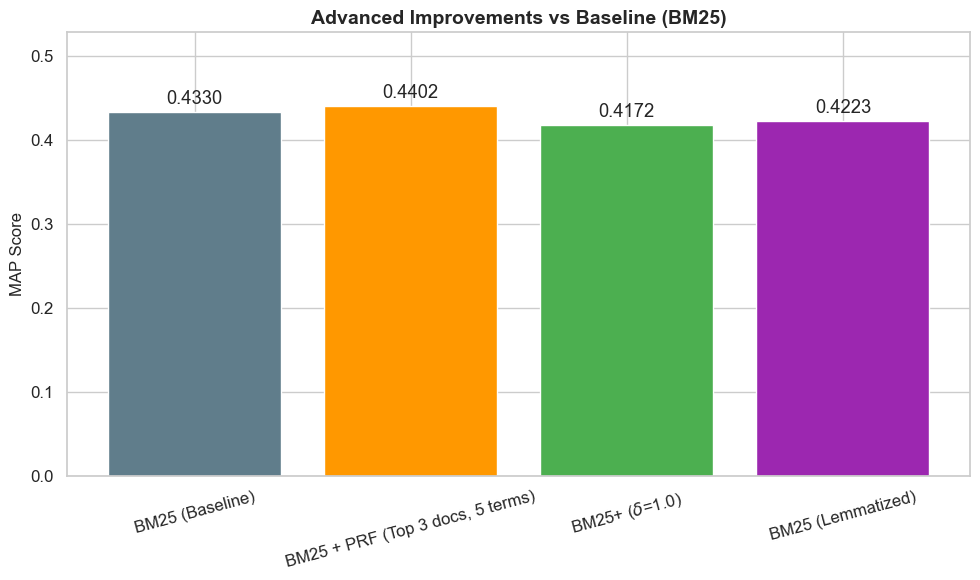

In [6]:
df = pd.DataFrame(all_metrics).T
df = df[['MAP', 'MRR', f'P@{K}', f'R@{K}', f'F1@{K}']]
display(df)

# Plotting MAP comparison
fig, ax = plt.subplots(figsize=(10, 6))
models = df.index
maps = df['MAP']
bars = ax.bar(models, maps, color=['#607D8B', '#FF9800', '#4CAF50', '#9C27B0'])
ax.set_ylim(0, max(maps) * 1.2)
ax.set_ylabel('MAP Score', fontsize=12)
ax.set_title('Advanced Improvements vs Baseline (BM25)', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
for bar, v in zip(bars, maps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{v:.4f}", ha='center', va='bottom')
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'advanced_improvements.png'), dpi=150, bbox_inches='tight')
plt.show()
